In [1]:
import numpy as np
import pandas as pd
import math

import pymcdm

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def f_three_value(c1, c2):
    if c1 < c2:
        return 1
    if c1 == c2:
        return 0.5
    return 0

def f_ratio_based(c1, c2):
    if c1 < c2:
        return c2/c1
    if c1 == c2:
        return 1
    return 1 / (c1/c2)


def f_exponential(c1, c2, beta=0.5):
    if c1 == c2:
        return 1
    return math.exp(beta * (c2 - c1))

In [4]:
def RANCOM(ranking, f, tie_value, verbose=False):
    """Calculate criteria weights based on the given numerical hierarchy. Lower value means higher relevance.

    Parameters
    ----------
        ranking : ndarray
            Numerical values for criteria relevance (lower - more relevant).
        
        f : callable
            Objective function used for filling the Matrix of ranking Comparison (MAC).

        tie_value: float
            Value used to fill MAC when tie is noted

    Returns
    -------
        ndarray
            Criteria weights in range 0-1.
    """

    def build_mac(ranking):
        co = np.array(list(ranking))

        mac = np.diag(np.ones(co.shape[0]) * tie_value)
        for i in range(mac.shape[0]):
            for j in range(i+1, mac.shape[1]):
                v = f(co[i], co[j])
                mac[i, j] = v
                if tie_value == 1:
                    mac[j,i] = 1 / v
                else:
                    mac[j, i] = 1 - v
        return mac

    def get_weights(ranking):
        mac = build_mac(ranking)
        scw = np.sum(mac, axis=1)
        p = scw / np.sum(scw)
        

        if verbose:
            print('------- MAC ---------')
            print(mac)
            print('------- SCW ---------')
            print(scw)
            print('------- WEIGHTS ---------')
            print(p)

        return p, mac

    return get_weights(ranking)
    

Problem: Smart grid / energy management

Criteria

- Cost 
- CO₂ emissions
- Grid stability
- Renewable usage
- Demand satisfaction
- Storage efficiency

Agent type

- Cost-focused – prioritises cost, pays less attention to emissions and storage
- Eco-focused – prioritises renewable energy and emissions, pays less attention to cost
- Stability-focused – prioritises grid stability and demand satisfaction
- Balanced – treats all criteria equally

Time points and strategic objectives

| Time | Strategic Goal                  |
| ---- | ------------------------------- |
| t0   | Minimize operational cost       |
| t1   | Maximize renewable energy usage |
| t2   | Ensure grid stability           |
| t3   | Reduce CO₂ emissions            |
| t4   | Maximize demand satisfaction    |
| t5   | Minimize operational cost       |
| t6   | Maximize renewable energy usage |
| t7   | Ensure grid stability           |


Agent allocation strategy

| Time | Strategic Goal                  | Dominant Type     | Agents in system (10 total)            |
| ---- | ------------------------------- | ----------------- | -------------------------------------- |
| t0   | Minimize operational cost       | Cost-focused      | Cost:4, Eco:2, Stability:2, Balanced:2 |
| t1   | Maximize renewable energy usage | Eco-focused       | Cost:2, Eco:4, Stability:2, Balanced:2 |
| t2   | Ensure grid stability           | Stability-focused | Cost:2, Eco:2, Stability:4, Balanced:2 |
| t3   | Reduce CO₂ emissions            | Eco-focused       | Cost:2, Eco:4, Stability:2, Balanced:2 |
| t4   | Maximize demand satisfaction    | Stability-focused | Cost:2, Eco:2, Stability:4, Balanced:2 |
| t5   | Minimize operational cost       | Cost-focused      | Cost:4, Eco:2, Stability:2, Balanced:2 |
| t6   | Maximize renewable energy usage | Eco-focused       | Cost:2, Eco:4, Stability:2, Balanced:2 |
| t7   | Ensure grid stability           | Stability-focused | Cost:2, Eco:2, Stability:4, Balanced:2 |


Rankings

In [5]:
import numpy as np

# t0 – Minimize operational cost (Cost:4, Eco:2, Stability:2, Balanced:2)
t0_rankings = np.array([
    [1, 5, 3, 6, 2, 4],  # A1, Cost-focused
    [1, 4, 2, 6, 3, 5],  # A2, Cost-focused
    [1, 5, 3, 6, 2, 4],  # A3, Cost-focused
    [1, 3, 4, 6, 2, 5],  # A4, Cost-focused
    [3, 2, 5, 1, 4, 6],  # A5, Eco-focused
    [2, 4, 5, 1, 3, 6],  # A6, Eco-focused
    [3, 5, 1, 6, 2, 4],  # A7, Stability-focused
    [4, 5, 1, 6, 2, 3],  # A8, Stability-focused
    [1, 4, 3, 2, 5, 6],  # A9, Balanced
    [1, 5, 2, 3, 4, 6],  # A10, Balanced
])

# t1 – Maximize renewable energy usage (Cost:2, Eco:4, Stability:2, Balanced:2)
t1_rankings = np.array([
    [2, 5, 3, 1, 4, 6],  # A1, Cost-focused
    [2, 4, 3, 1, 5, 6],  # A2, Cost-focused
    [3, 2, 5, 1, 4, 6],  # A3, Eco-focused
    [3, 5, 4, 1, 2, 6],  # A4, Eco-focused
    [4, 2, 5, 1, 3, 6],  # A5, Eco-focused
    [4, 3, 5, 1, 2, 6],  # A6, Eco-focused
    [3, 5, 2, 1, 4, 6],  # A7, Stability-focused
    [4, 5, 2, 1, 3, 6],  # A8, Stability-focused
    [3, 4, 5, 1, 2, 6],  # A9, Balanced
    [3, 5, 4, 1, 2, 6],  # A10, Balanced
])

# t2 – Ensure grid stability (Cost:2, Eco:2, Stability:4, Balanced:2)
t2_rankings = np.array([
    [2, 5, 1, 4, 3, 6],  # A1, Cost-focused
    [2, 5, 1, 4, 3, 6],  # A2, Cost-focused
    [3, 2, 1, 4, 5, 6],  # A3, Eco-focused
    [4, 2, 1, 3, 5, 6],  # A4, Eco-focused
    [3, 5, 1, 4, 2, 6],  # A5, Stability-focused
    [4, 5, 1, 3, 2, 6],  # A6, Stability-focused
    [3, 5, 1, 4, 2, 6],  # A7, Stability-focused
    [4, 5, 1, 3, 2, 6],  # A8, Stability-focused
    [3, 4, 1, 5, 2, 6],  # A9, Balanced
    [3, 5, 1, 4, 2, 6],  # A10, Balanced
])

# t3 – Reduce CO₂ emissions (Cost:2, Eco:4, Stability:2, Balanced:2)
t3_rankings = np.array([
    [1, 2, 3, 4, 5, 6],  # A1, Cost-focused
    [1, 2, 3, 4, 5, 6],  # A2, Cost-focused
    [3, 1, 5, 2, 4, 6],  # A3, Eco-focused
    [4, 1, 5, 2, 3, 6],  # A4, Eco-focused
    [5, 1, 3, 2, 4, 6],  # A5, Eco-focused
    [3, 1, 4, 2, 5, 6],  # A6, Eco-focused
    [4, 5, 1, 2, 3, 6],  # A7, Stability-focused
    [4, 5, 1, 3, 2, 6],  # A8, Stability-focused
    [3, 2, 1, 4, 5, 6],  # A9, Balanced
    [3, 1, 2, 4, 5, 6],  # A10, Balanced
])

# t4 – Maximize demand satisfaction (Cost:2, Eco:2, Stability:4, Balanced:2)
t4_rankings = np.array([
    [2, 5, 3, 4, 1, 6],  # A1, Cost-focused
    [2, 5, 4, 3, 1, 6],  # A2, Cost-focused
    [3, 2, 4, 1, 5, 6],  # A3, Eco-focused
    [4, 2, 3, 1, 5, 6],  # A4, Eco-focused
    [1, 5, 2, 4, 3, 6],  # A5, Stability-focused
    [1, 5, 3, 4, 2, 6],  # A6, Stability-focused
    [1, 4, 2, 3, 5, 6],  # A7, Stability-focused
    [1, 4, 3, 2, 5, 6],  # A8, Stability-focused
    [1, 3, 2, 4, 5, 6],  # A9, Balanced
    [1, 4, 2, 3, 5, 6],  # A10, Balanced
])

# t5 – Minimize operational cost (Cost:4, Eco:2, Stability:2, Balanced:2)
t5_rankings = np.array([
    [1, 5, 3, 4, 2, 6],  # A1, Cost-focused
    [1, 5, 2, 4, 3, 6],  # A2, Cost-focused
    [1, 4, 3, 5, 2, 6],  # A3, Cost-focused
    [1, 3, 4, 5, 2, 6],  # A4, Cost-focused
    [4, 2, 5, 1, 3, 6],  # A5, Eco-focused
    [2, 4, 5, 1, 3, 6],  # A6, Eco-focused
    [3, 5, 1, 4, 2, 6],  # A7, Stability-focused
    [4, 5, 1, 3, 2, 6],  # A8, Stability-focused
    [1, 4, 3, 2, 5, 6],  # A9, Balanced
    [1, 5, 2, 3, 4, 6],  # A10, Balanced
])

# t6 – Maximize renewable energy usage (Cost:2, Eco:4, Stability:2, Balanced:2)
t6_rankings = np.array([
    [2, 5, 3, 1, 4, 6],  # A1, Cost-focused
    [2, 5, 3, 1, 4, 6],  # A2, Cost-focused
    [1, 2, 5, 3, 4, 6],  # A3, Eco-focused
    [1, 3, 4, 2, 5, 6],  # A4, Eco-focused
    [1, 2, 5, 3, 4, 6],  # A5, Eco-focused
    [1, 2, 4, 3, 5, 6],  # A6, Eco-focused
    [3, 5, 1, 2, 4, 6],  # A7, Stability-focused
    [3, 5, 1, 2, 4, 6],  # A8, Stability-focused
    [1, 4, 3, 2, 5, 6],  # A9, Balanced
    [1, 5, 2, 3, 4, 6],  # A10, Balanced
])

# t7 – Ensure grid stability (Cost:2, Eco:2, Stability:4, Balanced:2)
t7_rankings = np.array([
    [2, 5, 1, 4, 3, 6],  # A1, Cost-focused
    [2, 5, 1, 4, 3, 6],  # A2, Cost-focused
    [1, 2, 5, 3, 4, 6],  # A3, Eco-focused
    [1, 2, 5, 3, 4, 6],  # A4, Eco-focused
    [3, 5, 1, 4, 2, 6],  # A5, Stability-focused
    [3, 5, 1, 4, 2, 6],  # A6, Stability-focused
    [3, 5, 1, 4, 2, 6],  # A7, Stability-focused
    [3, 5, 1, 4, 2, 6],  # A8, Stability-focused
    [1, 4, 3, 2, 5, 6],  # A9, Balanced
    [1, 5, 2, 3, 4, 6],  # A10, Balanced
])

In [6]:
def group_rancom(rankings, f, tie):
    """Compute compromise weights for a group of agents."""
    agent_weights = []
    for r in rankings:
        w, _ = RANCOM(r, f, tie)
        agent_weights.append(w)

    agent_weights = np.array(agent_weights)
    group_weights = np.mean(agent_weights, axis=0)

    group_weights /= np.sum(group_weights)
    return group_weights

Calculations

In [7]:
time_rankings = [t0_rankings, t1_rankings, t2_rankings, t3_rankings,
                 t4_rankings, t5_rankings, t6_rankings, t7_rankings]


Independent in time

In [8]:

temporal_weights = []

for t, rankings in enumerate(time_rankings):
    w_group = group_rancom(rankings, f_three_value, 0.5)
    temporal_weights.append(w_group)
    print(f"t{t} group weights:", np.round(w_group, 3))

temporal_weights = np.array(temporal_weights)  


t0 group weights: [0.303 0.105 0.19  0.156 0.158 0.088]
t1 group weights: [0.139 0.116 0.121 0.408 0.148 0.068]
t2 group weights: [0.139 0.108 0.408 0.11  0.166 0.068]
t3 group weights: [0.175 0.282 0.21  0.156 0.109 0.068]
t4 group weights: [0.31  0.118 0.156 0.184 0.165 0.068]
t5 group weights: [0.299 0.105 0.19  0.176 0.161 0.068]
t6 group weights: [0.313 0.126 0.18  0.218 0.096 0.068]
t7 group weights: [0.259 0.108 0.295 0.122 0.148 0.068]


With temporal modification

In [9]:
def temporal_rancom_with_correction(time_rankings, f, tie, alpha=0.5):
    """
    time_rankings: a NumPy array [t0, t1, ...] of agent rankings
    f: function for RANCOM
    alpha: influence of the previous state (0=no influence, 1=previous state only)
    """
    temporal_weights = []
    prev_weights = None

    for t, rankings in enumerate(time_rankings):
        w_group = group_rancom(rankings, f, tie)

        if prev_weights is not None:

            w_group = alpha * prev_weights + (1 - alpha) * w_group
            w_group /= np.sum(w_group) 

        temporal_weights.append(w_group)
        prev_weights = w_group.copy()
        print(f"t{t} group weights (corrected):", np.round(w_group, 3))

    return np.array(temporal_weights)

In [10]:
temporal_weights_corrected = temporal_rancom_with_correction(time_rankings, f_three_value, 1, alpha=0.5)
temporal_weights_corrected

t0 group weights (corrected): [0.303 0.105 0.19  0.156 0.158 0.088]
t1 group weights (corrected): [0.221 0.111 0.155 0.282 0.153 0.078]
t2 group weights (corrected): [0.18  0.109 0.282 0.196 0.159 0.073]
t3 group weights (corrected): [0.178 0.195 0.246 0.176 0.134 0.07 ]
t4 group weights (corrected): [0.244 0.157 0.201 0.18  0.149 0.069]
t5 group weights (corrected): [0.271 0.131 0.196 0.178 0.155 0.069]
t6 group weights (corrected): [0.292 0.128 0.188 0.198 0.126 0.068]
t7 group weights (corrected): [0.275 0.118 0.241 0.16  0.137 0.068]


array([[0.30272109, 0.10544218, 0.18979592, 0.15646259, 0.15782313,
        0.0877551 ],
       [0.22108844, 0.11054422, 0.15544218, 0.28231293, 0.15272109,
        0.07789116],
       [0.18027211, 0.10935374, 0.28180272, 0.1962585 , 0.15935374,
        0.07295918],
       [0.17755102, 0.1954932 , 0.2460034 , 0.17636054, 0.13409864,
        0.0704932 ],
       [0.24353741, 0.15659014, 0.20123299, 0.18001701, 0.14936224,
        0.0692602 ],
       [0.27142857, 0.13101616, 0.19551446, 0.17810374, 0.15529337,
        0.06864371],
       [0.29217687, 0.12843325, 0.18755315, 0.19789541, 0.12560587,
        0.06833546],
       [0.27534014, 0.11829826, 0.24139562, 0.16017219, 0.13661246,
        0.06818134]])

Visualizations

In [ ]:
def weights_plot(weights,
                 xticklabels=None,
                 bar_kwargs=dict(),
                 legend_ncol=5,
                 colors=None,
                 show_text=False,
                 show_text_threshold=0.07,
                 text_kwargs=dict(),
                 title=None,
                 ax=None):
    """ Function for criteria weights visualisation.

        Parameters
        ----------
            weights : ndarray
                Matrix of weights. Each row is a vector of weights.

            xticklabels : None or Iterable
                Labels for bars (names for the different weighting methods).

            bar_kwargs : dict
                Keywors arguments to pass into bar function.

            legend_ncol : int
                Number of columns in legend.

            colors : Iterable or None
                Colors for bars. If there are less colors then criteria, then colors will be cycled.

            show_text : bool
                Show the weights values as text on bars.

            show_text_threshold : float
                The smallest value of the weights to be show.
                The values below this threshold wont be shown.

            text_kwargs : dict
                Keyword arguments for weights text.

            ax : Axes or None
                Axes object to dwaw on.

        Returns
        -------
            ax : Axes
                Axes object on which plot were drawn.

        Examples
        --------
            >>> import numpy as np
            >>> import matplotlib.pyplot as plt
            >>> from pymcdm.visuals import weights_plot
            >>> w = np.array([[0.3, 0.2, 0.5],
            ...              [0.2, 0.5, 0.3]])
            >>> weights_plot(w)
            >>> plt.show()
    """

    weights = np.array(weights).T

    if ax is None:
        ax = plt.gca()

    if xticklabels is None:
        xticklabels = [f'$M_{{{i + 1}}}$' for i in range(weights.shape[1])]

    bar_kwargs = dict(
        linewidth=1,
        edgecolor='black'
    ) | bar_kwargs

    text_kwargs = dict(
        ha='center',
        va='center',
        color='w',
        fontweight='bold',
        fontsize=8
    ) | text_kwargs

    bottom = np.zeros(weights.shape[1], dtype=float)
    for i, alt in enumerate(weights):
        if colors is not None:
            bar_kwargs['color'] = colors[i % len(colors)]

        ax.bar(xticklabels, alt, label=f'$C_{i + 1}$', bottom=bottom, **bar_kwargs)
        bottom += alt

    if show_text:
        bottom = np.zeros(weights.shape[1])
        for j, w in enumerate(weights):
            means = (w / 2) + bottom
            for i in range(len(w)):
                if w[i] >= show_text_threshold:
                    ax.text(
                        i,
                        means[i],
                        f'{w[i]:0.3f}',
                        **text_kwargs
                    )
            bottom += w

    ax.grid(alpha=0.5, linestyle='--')
    ax.set_axisbelow(True)

    ax.set_xticks(range(len(xticklabels)), labels=xticklabels)
    ax.set_xticklabels(xticklabels)
    ax.set_xlabel('Method')

    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylabel('Weight value')

    if title:
        ax.set_title(title, fontsize=14, loc='left', x=0.0)

    ax.legend(bbox_to_anchor=(0.4, 1.02, 0.6, .102), loc='lower left',
              ncol=legend_ncol, mode="expand", borderaxespad=0.)

    return ax


In [11]:
import matplotlib.cm as cm
def visual_weights(weights, title=None, filename=None):
    time_points = ["T0","T1","T2","T3","T4","T5","T6","T7"]
    colors = cm.Set2.colors[:6]
    plt.figure(figsize=(10,4))
    ax = weights_plot(
        weights, 
        time_points, 
        legend_ncol=6,
        show_text=True,  
        text_kwargs={'fontsize':10, 'fontweight':'bold'}, 
        title=title
        )
    plt.xlabel('Timeline', fontsize=14)
    plt.ylabel('Weight value', fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    legend = ax.get_legend()
    for text in legend.get_texts():
        text.set_fontsize(12)

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

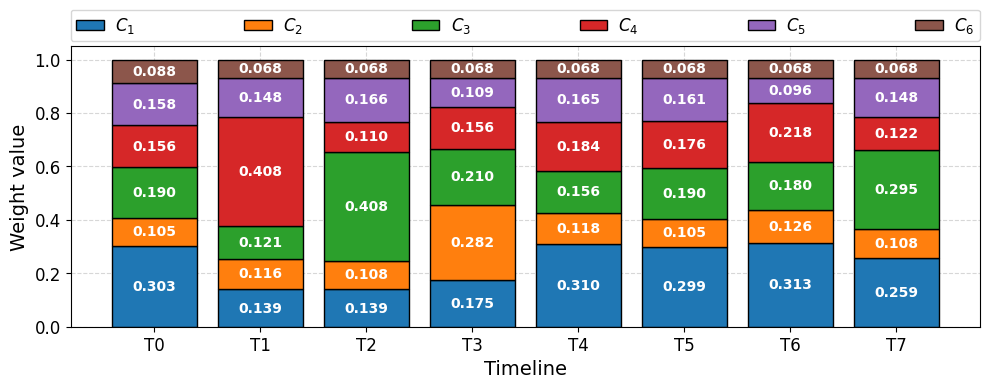

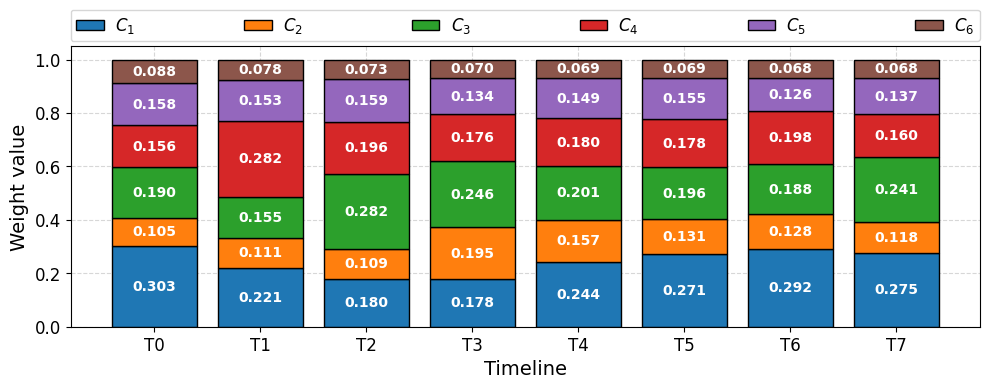

In [12]:
visual_weights(temporal_weights)
visual_weights(temporal_weights_corrected)

Different alpha

t0 group weights (corrected): [0.303 0.105 0.19  0.156 0.158 0.088]
t1 group weights (corrected): [0.188 0.113 0.142 0.333 0.151 0.074]
t2 group weights (corrected): [0.154 0.109 0.328 0.177 0.161 0.07 ]
t3 group weights (corrected): [0.169 0.23  0.246 0.163 0.125 0.069]
t4 group weights (corrected): [0.267 0.151 0.183 0.177 0.153 0.068]
t5 group weights (corrected): [0.29  0.119 0.188 0.177 0.159 0.068]
t6 group weights (corrected): [0.306 0.124 0.182 0.205 0.115 0.068]
t7 group weights (corrected): [0.273 0.113 0.261 0.147 0.138 0.068]


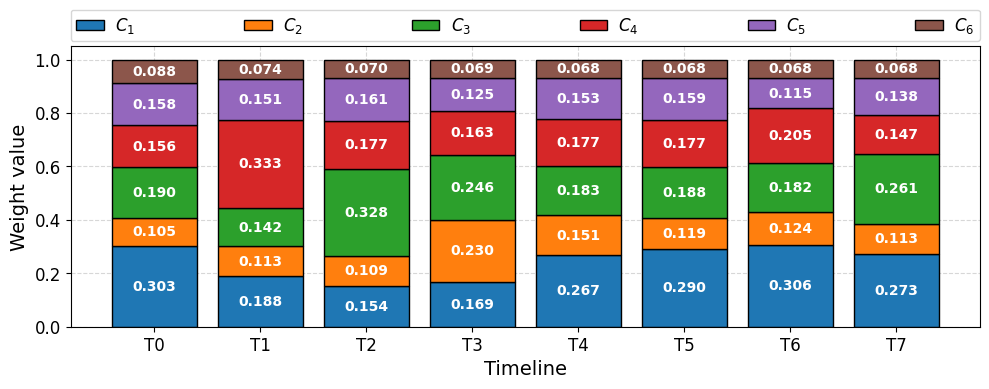

t0 group weights (corrected): [0.303 0.105 0.19  0.156 0.158 0.088]
t1 group weights (corrected): [0.221 0.111 0.155 0.282 0.153 0.078]
t2 group weights (corrected): [0.18  0.109 0.282 0.196 0.159 0.073]
t3 group weights (corrected): [0.178 0.195 0.246 0.176 0.134 0.07 ]
t4 group weights (corrected): [0.244 0.157 0.201 0.18  0.149 0.069]
t5 group weights (corrected): [0.271 0.131 0.196 0.178 0.155 0.069]
t6 group weights (corrected): [0.292 0.128 0.188 0.198 0.126 0.068]
t7 group weights (corrected): [0.275 0.118 0.241 0.16  0.137 0.068]


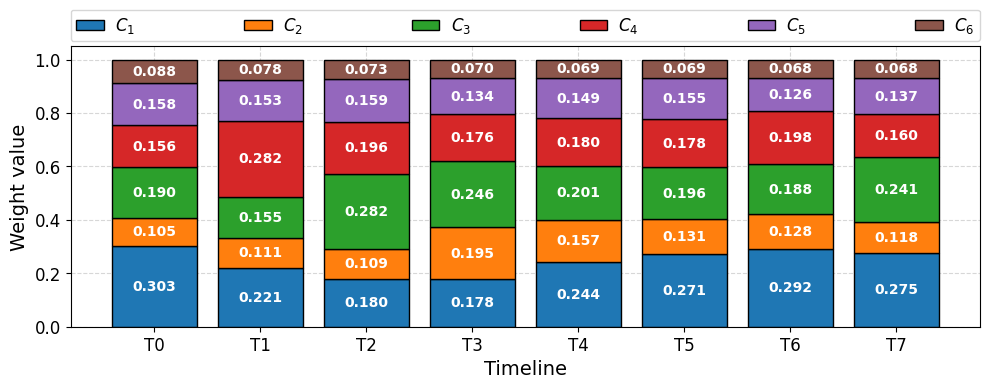

t0 group weights (corrected): [0.303 0.105 0.19  0.156 0.158 0.088]
t1 group weights (corrected): [0.254 0.109 0.169 0.232 0.155 0.082]
t2 group weights (corrected): [0.219 0.108 0.241 0.195 0.158 0.078]
t3 group weights (corrected): [0.206 0.16  0.232 0.184 0.143 0.075]
t4 group weights (corrected): [0.237 0.148 0.209 0.184 0.15  0.073]
t5 group weights (corrected): [0.256 0.135 0.203 0.181 0.153 0.071]
t6 group weights (corrected): [0.273 0.132 0.196 0.192 0.136 0.07 ]
t7 group weights (corrected): [0.269 0.125 0.226 0.171 0.139 0.07 ]


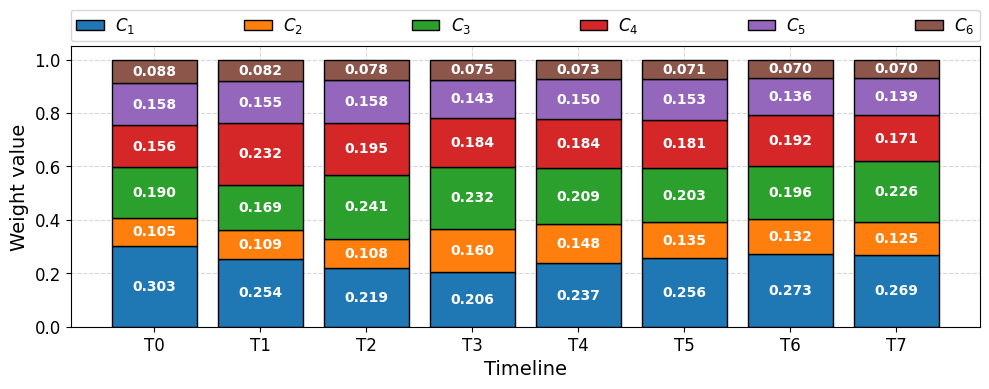

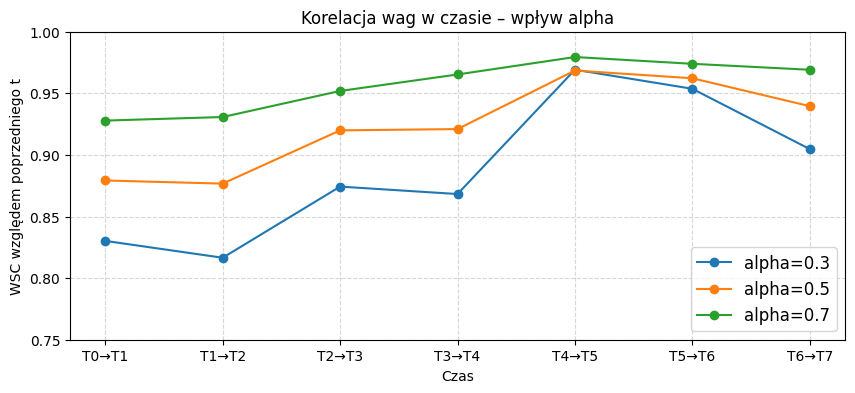

In [13]:
time_points = ["T0","T1","T2","T3","T4","T5","T6","T7"]

wsc_dict = {}
alphas = [0.3, 0.5, 0.7]
for alpha in alphas:
    temporal_weights_corrected_alpha = temporal_rancom_with_correction(time_rankings, f_ratio_based, 1, alpha=alpha)
    visual_weights(temporal_weights_corrected_alpha)

    wsc_values = []
    for t in range(1, temporal_weights_corrected_alpha.shape[0]):
        prev = temporal_weights_corrected_alpha[t-1]
        curr = temporal_weights_corrected_alpha[t]
        wsc = pymcdm.correlations.wsc(curr, prev)
        wsc_values.append(wsc)
    wsc_dict[alpha] = np.array(wsc_values)

time_pairs = [f"{time_points[t-1]}→{time_points[t]}" for t in range(1, len(time_points))]

plt.figure(figsize=(10,4))
for alpha in alphas:
    plt.plot(range(1,8), wsc_dict[alpha], marker='o', label=fr'Correction $\alpha={alpha}$')
plt.xticks(range(1,8), time_pairs)
plt.ylabel("Weights Similarity Coefficient ($WSC$)", fontsize=12)
plt.xlabel("Timeline", fontsize=12)
plt.ylim(0.75,1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('img/wsc_alpha.png')
plt.show()

Different relationship functions

t0 group weights (corrected): [0.303 0.105 0.19  0.156 0.158 0.088]
t1 group weights (corrected): [0.221 0.111 0.155 0.282 0.153 0.078]
t2 group weights (corrected): [0.18  0.109 0.282 0.196 0.159 0.073]
t3 group weights (corrected): [0.178 0.195 0.246 0.176 0.134 0.07 ]
t4 group weights (corrected): [0.244 0.157 0.201 0.18  0.149 0.069]
t5 group weights (corrected): [0.271 0.131 0.196 0.178 0.155 0.069]
t6 group weights (corrected): [0.292 0.128 0.188 0.198 0.126 0.068]
t7 group weights (corrected): [0.275 0.118 0.241 0.16  0.137 0.068]


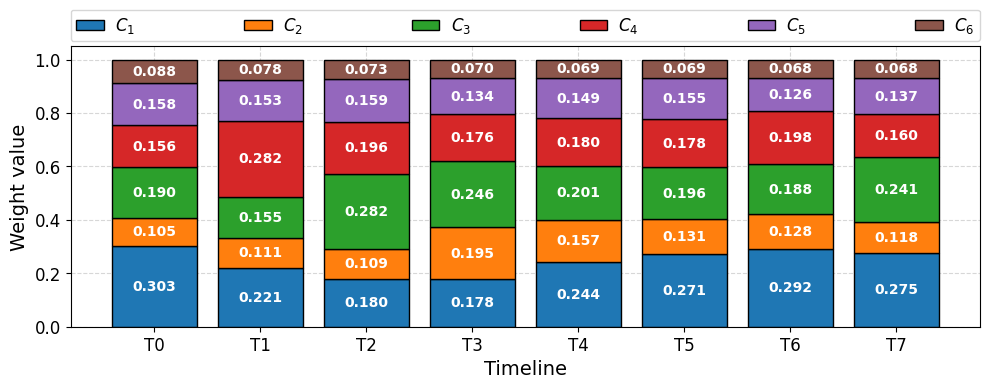

t0 group weights (corrected): [0.261 0.128 0.2   0.122 0.2   0.089]
t1 group weights (corrected): [0.225 0.133 0.175 0.214 0.194 0.058]
t2 group weights (corrected): [0.207 0.128 0.24  0.182 0.2   0.043]
t3 group weights (corrected): [0.198 0.186 0.223 0.191 0.167 0.035]
t4 group weights (corrected): [0.232 0.165 0.214 0.195 0.161 0.032]
t5 group weights (corrected): [0.244 0.147 0.207 0.189 0.183 0.03 ]
t6 group weights (corrected): [0.258 0.148 0.198 0.214 0.153 0.029]
t7 group weights (corrected): [0.254 0.135 0.221 0.19  0.171 0.028]


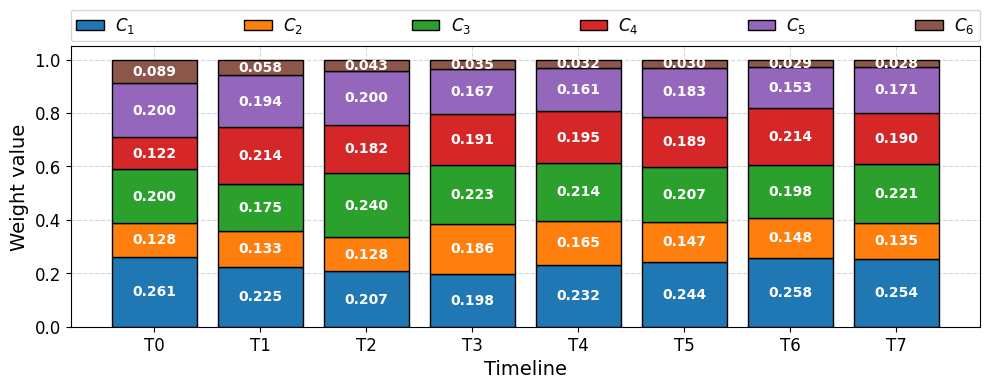

t0 group weights (corrected): [0.313 0.096 0.199 0.144 0.18  0.068]
t1 group weights (corrected): [0.234 0.104 0.16  0.279 0.172 0.051]
t2 group weights (corrected): [0.194 0.101 0.287 0.193 0.182 0.042]
t3 group weights (corrected): [0.185 0.197 0.251 0.185 0.142 0.038]
t4 group weights (corrected): [0.254 0.157 0.216 0.188 0.149 0.036]
t5 group weights (corrected): [0.281 0.126 0.207 0.183 0.168 0.035]
t6 group weights (corrected): [0.305 0.127 0.195 0.213 0.125 0.035]
t7 group weights (corrected): [0.291 0.113 0.248 0.17  0.144 0.034]


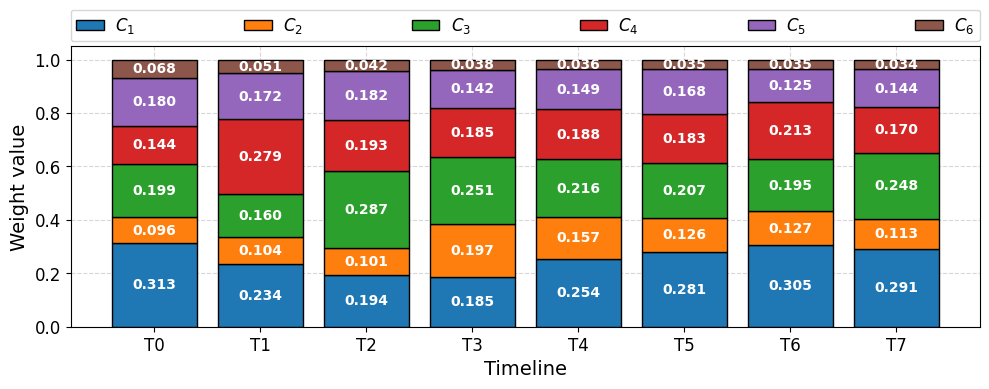

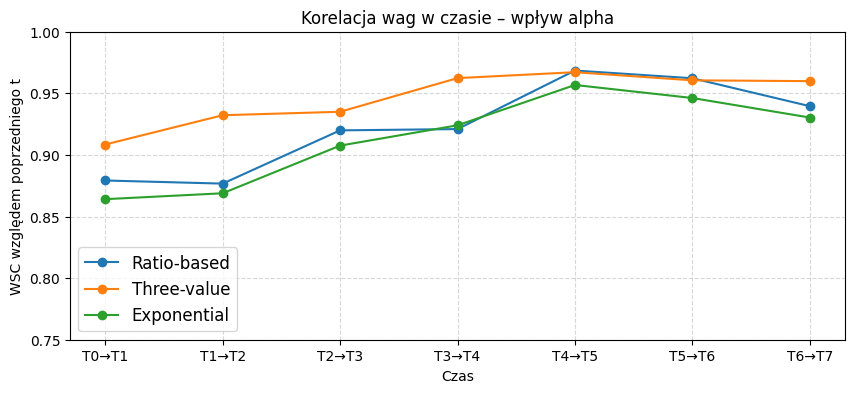

In [14]:
wsc_dict = {}
for f, tie, name in [[f_three_value, 0.5, 'Three-value'], [f_ratio_based, 1, 'Ratio-based'], [f_exponential, 1, 'Exponential']]:
    temporal_weights_corrected_fun = temporal_rancom_with_correction(time_rankings, f, tie, alpha=0.5)
    visual_weights(temporal_weights_corrected_fun)

    wsc_values = []
    for t in range(1, temporal_weights_corrected_fun.shape[0]):
        prev = temporal_weights_corrected_fun[t-1]
        curr = temporal_weights_corrected_fun[t]
        wsc = pymcdm.correlations.wsc(curr, prev)
        wsc_values.append(wsc)
    wsc_dict[name] = np.array(wsc_values)

time_pairs = [f"{time_points[t-1]}→{time_points[t]}" for t in range(1, len(time_points))]

plt.figure(figsize=(10,4))
for name in list(wsc_dict.keys()):
    plt.plot(range(1,8), wsc_dict[name], marker='o', label=f'{name}')
plt.xticks(range(1,8), time_pairs)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Weights Similarity Coefficient ($WSC$)", fontsize=12)
plt.ylim(0.75,1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('img/wsc_fun.png')
plt.show()